In [1]:
from sklearn.datasets  import load_digits
from sklearn.utils import shuffle

In [2]:
mnist = load_digits()

X, y = mnist.data, mnist.target


X, y = shuffle(X, y, random_state=0)
X.shape, y.shape

((1797, 64), (1797,))

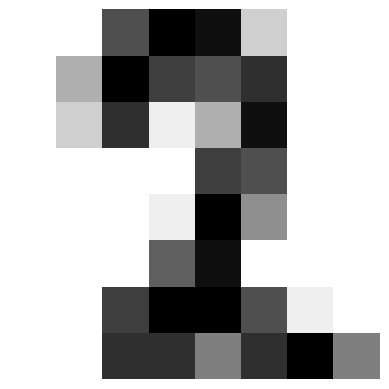

In [3]:
import matplotlib.pyplot as plt 

def plot_digit(image_data):
    image = image_data.reshape(8, 8)
    plt.imshow(image, cmap = "binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
from sklearn.linear_model import SGDClassifier

X_train, X_test, y_train, y_test = X[:1000], X[1000:], y[:1000], y[1000:]

y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)


sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_2)
sgd_clf.predict([some_digit])

array([ True])

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_predict = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3)
cm = confusion_matrix(y_train_2, y_train_predict)
cm

array([[899,   4],
       [  4,  93]])

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_train_2, y_train_predict)
recall = recall_score(y_train_2, y_train_predict)
f1 = f1_score(y_train_2, y_train_predict)



print("Precision:", precision)
print("Recall:", recall)    
print("F1 Score:", f1)

Precision: 0.9587628865979382
Recall: 0.9587628865979382
F1 Score: 0.9587628865979382
